<a href="https://colab.research.google.com/github/SambhavDjain/Ml_Projects/blob/main/Predicting_Student_Academic_Performance_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing essential libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# 1. Loading and Understanding Data

In [ ]:
# Create a categorical outcome (High/Low Performance) based on FinalMarks
data['Performance'] = np.where(data['FinalMarks'] >= 75, 1, 0)  # 1=High, 0=Low

data.head()



,Attendance,StudyHours,PreviousMarks,FinalMarks,Performance
0,78,4.0,70,65.75,0
1,60,3.1,79,57.43,0
2,86,5.1,87,72.60,0
3,99,1.7,59,64.28,0
4,63,3.7,64,57.66,0


In [ ]:
data.describe()


,Attendance,StudyHours,PreviousMarks,FinalMarks,Performance
count,50.00000,50.00000,50.000000,50.000000,50.00000
mean,79.02000,3.62600,72.740000,64.838400,0.14000
std,13.51566,1.31379,11.771307,7.655692,0.35051
min,60.00000,1.60000,50.000000,53.560000,0.00000
25%,67.00000,2.37500,64.000000,58.357500,0.00000
50%,78.00000,3.70000,71.500000,63.625000,0.00000
75%,91.50000,4.50000,83.750000,70.205000,0.00000
max,99.00000,6.00000,93.000000,83.480000,1.00000


# 2. Data Visualization

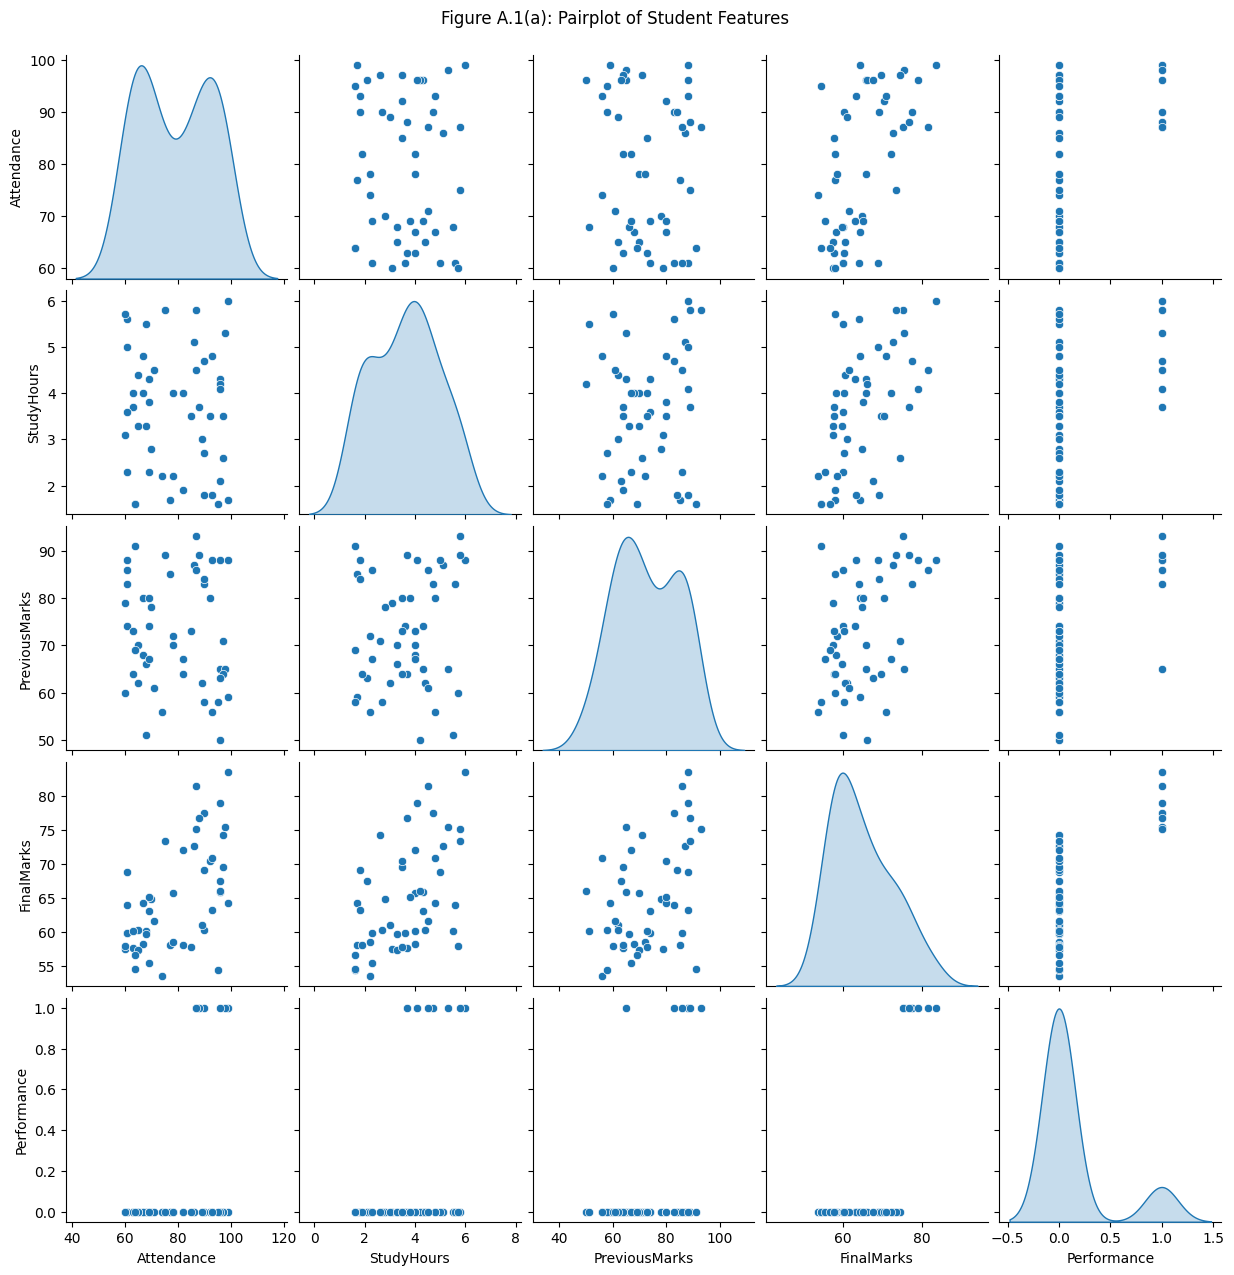

In [ ]:


# Pairplot to see relationships between variables
sns.pairplot(data, diag_kind='kde')
plt.suptitle("Figure A.1(a): Pairplot of Student Features", y=1.02)
plt.show()



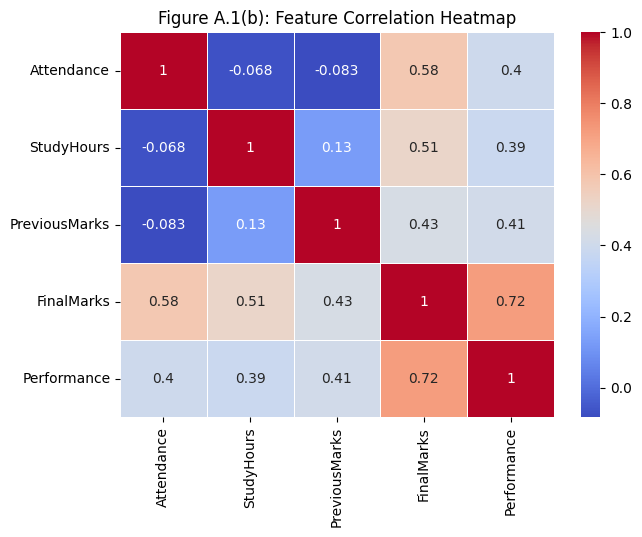

In [ ]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Figure A.1(b): Feature Correlation Heatmap")
plt.show()


# 3. Preparing Data for Model

In [ ]:
X = data[['Attendance', 'StudyHours', 'PreviousMarks']]
y = data['Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 4. Model Training


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# 5. Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² Score: -0.11
Mean Absolute Error: 0.10


# 6. Prediction And Accuracy

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%")


✅ Model Accuracy: 90.00%


# 5. Confusion Matrix

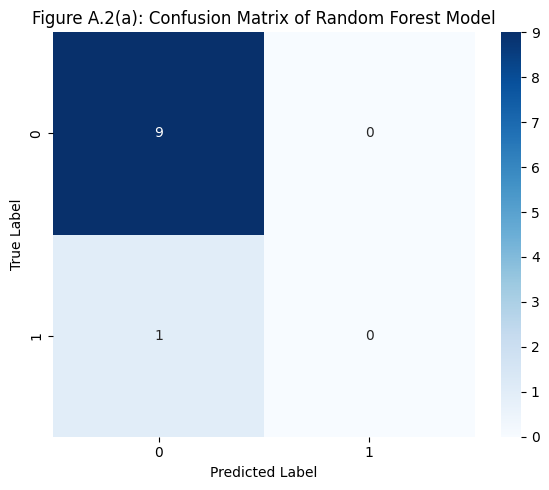

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Figure A.2(a): Confusion Matrix of Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 6. Result Visualization


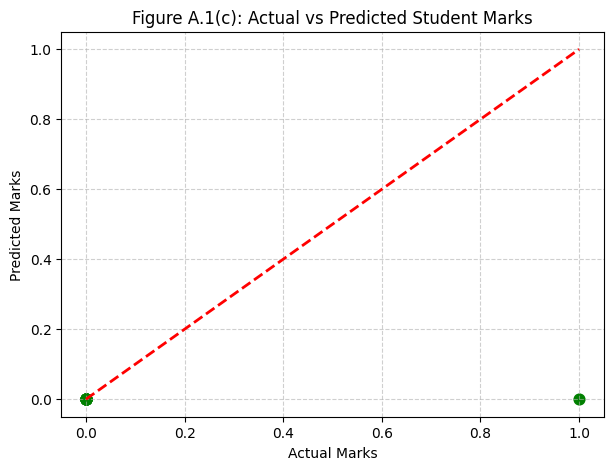

In [ ]:


# Plot 1: Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='green', s=60)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Figure A.1(c): Actual vs Predicted Student Marks")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

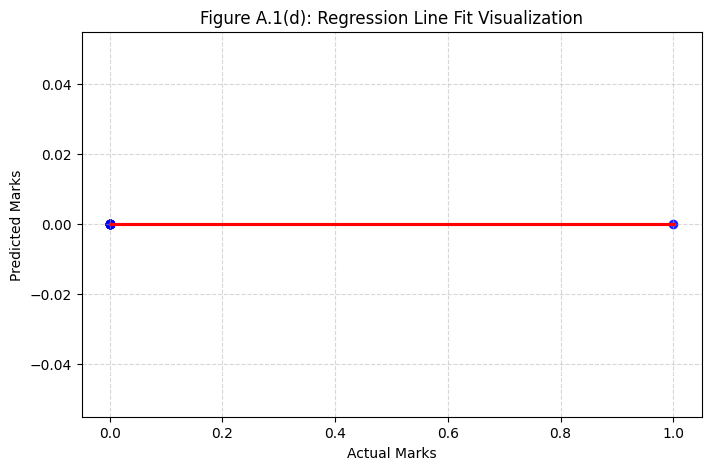

In [ ]:

# Plot 2: Regression Fit Visualization
plt.figure(figsize=(8, 5))
sns.regplot(x=y_test, y=y_pred, color='blue', line_kws={'color': 'red'})
plt.title("Figure A.1(d): Regression Line Fit Visualization")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

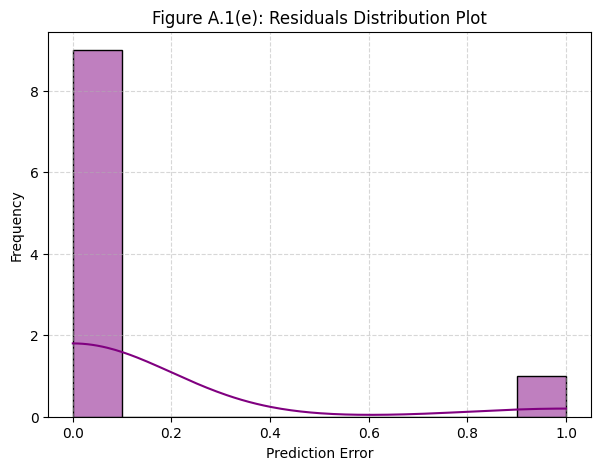

In [ ]:
# Plot 3: Residual Distribution
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='purple', bins=10)
plt.title("Figure A.1(e): Residuals Distribution Plot")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [ ]:
print("\nDisplaying first 10 student records:\n")
print(data.head(10).to_string(index=False))

print("\nTable A.1: Description of Dataset Features\n")
feature_description = pd.DataFrame({
    "Feature Name": [
        "Student_ID", "Attendance", "StudyHours", "PreviousMarks",
        "ParentalEducation", "InternetAccess", "FinalMarks"
    ],

"Description": [
        "Unique ID for each student",
        "Percentage of classes attended",
        "Average study time per day (hours)",
        "Internal assessment score",
        "Education level of parents",
        "Internet availability (Yes/No)",
        "Final examination marks"
    ],
    "Type": [
        "Integer", "Float", "Float", "Integer",
        "Categorical", "Boolean", "Integer"
    ]
})

print(feature_description.to_string(index=False))


Displaying first 10 student records:

 Attendance  StudyHours  PreviousMarks  FinalMarks  Performance
         78         4.0             70       65.75            0
         60         3.1             79       57.43            0
         86         5.1             87       72.60            0
         99         1.7             59       64.28            0
         63         3.7             64       57.66            0
         96         4.3             65       65.90            0
         69         4.3             74       63.05            0
         74         2.2             56       53.56            0
         70         2.8             78       64.88            0
         61         3.6             74       59.85            0

Table A.1: Description of Dataset Features

     Feature Name                        Description        Type
       Student_ID         Unique ID for each student     Integer
       Attendance     Percentage of classes attended       Float
       StudyHours